# Natural Language Processing (NLP)

**Natural Language Processing (NLP) is a field that combines computer science, artificial intelligence and linguistics to enable computers to understand, process and generate human language in a meaningful way.** With the growing amount of text data from social media, websites and other sources, NLP is becoming a key tool to gain insights and automate tasks like analyzing text or translating languages.

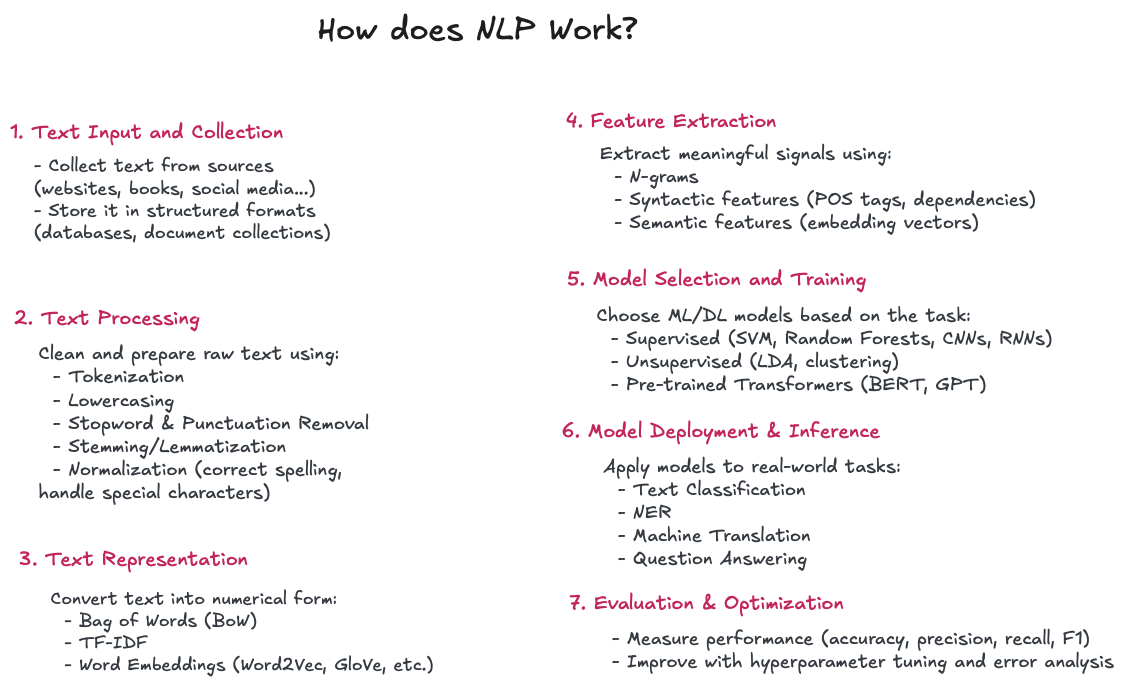

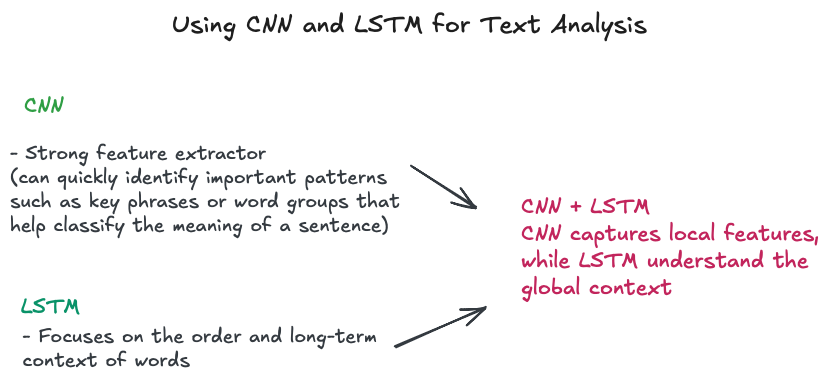

In [1]:
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.nn.utils.rnn import pad_sequence
from collections import Counter
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("emotions-dataset.csv")
df

,message,emotion
0,i used to be able to hang around talk with the...,anger
1,i get made to feel left out and unimportant in...,sadness
2,i wasnt going to post today as i am feeling qu...,sadness
3,i feel extremely delicate and a bit helpless,love
4,i feel frightened that i might fail to notice ...,fear
...,...,...
11995,i feel useless for wasting k hours k just for ...,sadness
11996,i feel rushed and pulled and rung out and i kn...,anger
11997,i feel absolutely disgusted,anger
11998,i know that we are all sinners and fall short ...,sadness


Check if the dataset is balanced.

<Axes: xlabel='emotion'>

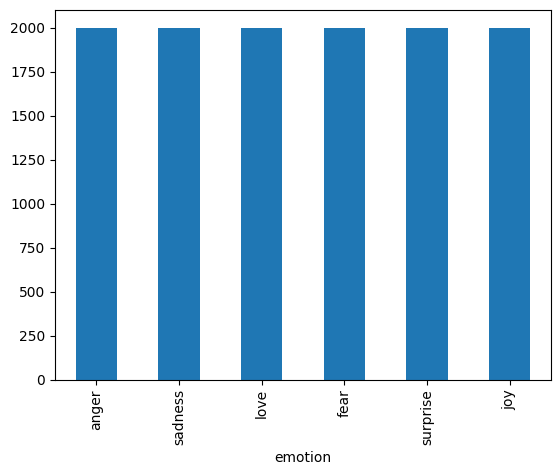

In [3]:
df["emotion"].value_counts().plot.bar()

Check if there are missing values.

In [4]:
df.isnull().sum()

message    0
emotion    0
dtype: int64

Plot the distribution of words per text.

<Axes: ylabel='Frequency'>

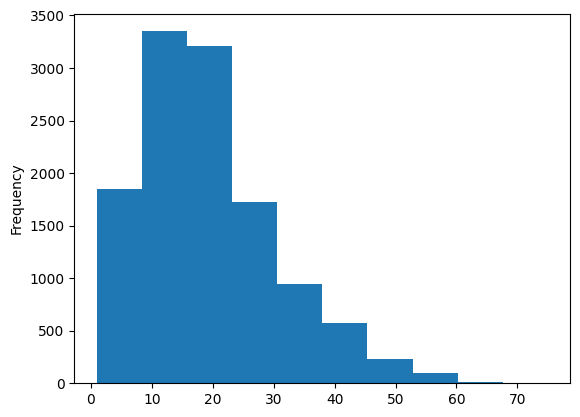

In [5]:
df["message"].str.split(" ").apply(len).plot.hist()

<Axes: >

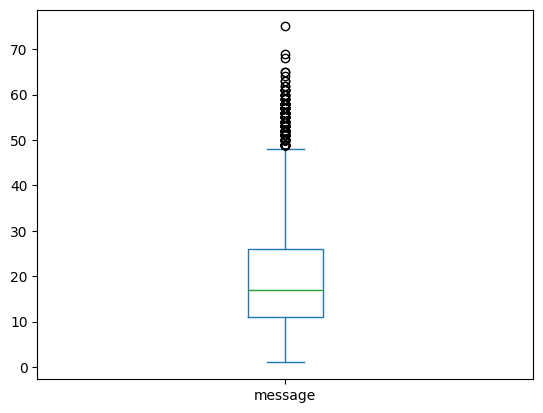

In [6]:
df["message"].str.split().apply(len).plot.box()

In [7]:
df = df[df["message"].str.split().apply(len) < 45].copy(deep=True)
df

,message,emotion
0,i used to be able to hang around talk with the...,anger
1,i get made to feel left out and unimportant in...,sadness
3,i feel extremely delicate and a bit helpless,love
4,i feel frightened that i might fail to notice ...,fear
5,i feel stubborn because i just want my seattle...,anger
...,...,...
11995,i feel useless for wasting k hours k just for ...,sadness
11996,i feel rushed and pulled and rung out and i kn...,anger
11997,i feel absolutely disgusted,anger
11998,i know that we are all sinners and fall short ...,sadness


<Axes: ylabel='Frequency'>

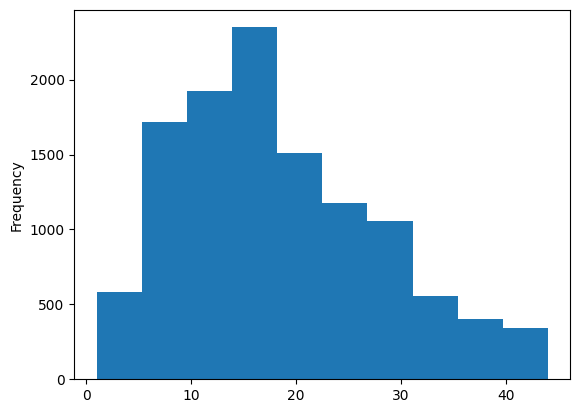

In [8]:
df["message"].str.split().apply(len).plot.hist()

<Axes: >

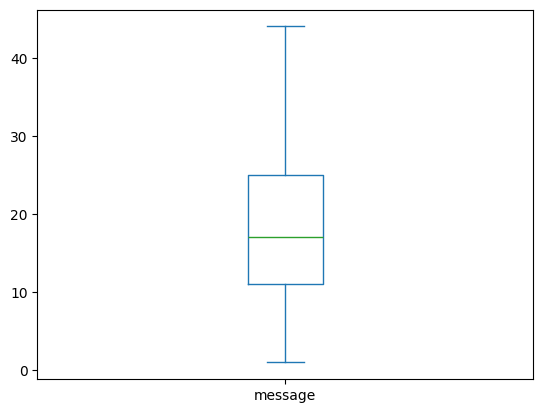

In [9]:
df["message"].str.split().apply(len).plot.box()

In [10]:
X, y, num_classes = df["message"], df["emotion"].astype("category").cat.codes, len(df["emotion"].unique())

In [11]:
train_X, test_X, train_y, test_y = train_test_split(
    X, y, test_size=0.2, random_state=42
)

train_X, val_X, train_y, val_y = train_test_split(
    train_X, train_y, test_size=0.2, random_state=42
)

In [12]:
def build_vocab(texts, max_vocab_size):
    counter = Counter()

    for sentence in texts:
        counter.update(sentence.split())

    # Special tokens
    vocab = {
        "<PAD>": 0,
        "<OOV>": 1
    }

    for idx, (word, _) in enumerate(
        counter.most_common(max_vocab_size - 2), start=2
    ):
        vocab[word] = idx

    return vocab

In [13]:
max_vocab_size = 10000
vocab = build_vocab(train_X.values, max_vocab_size)

In [14]:
def texts_to_sequences(texts, vocab):
    sequences = []

    for sentence in texts:
        seq = [
            vocab.get(word, vocab["<OOV>"])
            for word in sentence.split()
        ]
        sequences.append(seq)

    return sequences

In [15]:
train_X = texts_to_sequences(train_X.values, vocab)
val_X   = texts_to_sequences(val_X.values, vocab)
test_X  = texts_to_sequences(test_X.values, vocab)

In [16]:
def pad(sequences, pad_value=0):
    return pad_sequence(
        [torch.tensor(seq, dtype=torch.long) for seq in sequences],
        batch_first=True,
        padding_value=pad_value
    )


In [17]:
train_X = pad(train_X, pad_value=0)
val_X   = pad(val_X,pad_value=0)
test_X  = pad(test_X, pad_value=0)

In [18]:
train_y = torch.tensor(train_y.values, dtype=torch.long)
val_y   = torch.tensor(val_y.values, dtype=torch.long)
test_y  = torch.tensor(test_y.values, dtype=torch.long)

In [19]:
class CNN_LSTM(nn.Module):
    def __init__(self, vocab_size, num_classes):
        super().__init__()

        self.embedding = nn.Embedding(
            vocab_size, 128, padding_idx=0
        )

        self.conv1 = nn.Conv1d(128, 32, kernel_size=4, padding=2)
        self.pool1 = nn.MaxPool1d(2)

        self.conv2 = nn.Conv1d(32, 64, kernel_size=4, padding=2)
        self.pool2 = nn.MaxPool1d(2)

        self.lstm1 = nn.LSTM(64, 128, batch_first=True, dropout=0.2)
        self.lstm2 = nn.LSTM(128, 64, batch_first=True, dropout=0.1)

        self.fc = nn.Linear(64, num_classes)

    def forward(self, x):
        x = self.embedding(x)          # (batch, seq, 128)
        x = x.permute(0, 2, 1)         # (batch, 128, seq)

        x = self.pool1(F.relu(self.conv1(x)))
        x = self.pool2(F.relu(self.conv2(x)))

        x = x.permute(0, 2, 1)         # (batch, seq, features)

        x, _ = self.lstm1(x)
        _, (h, _) = self.lstm2(x)

        return self.fc(h[-1])

In [20]:
device = (
    "cuda" if torch.cuda.is_available() 
    else "mps" if torch.backends.mps.is_available() 
    else "cpu"
)

model = CNN_LSTM(
    vocab_size=len(vocab),
    num_classes=num_classes

).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

/Users/marijastojcheva/Downloads/i2ds/.venv/lib/python3.12/site-packages/torch/nn/modules/rnn.py:123: UserWarning: dropout option adds dropout after all but last recurrent layer, so non-zero dropout expects num_layers greater than 1, but got dropout=0.2 and num_layers=1
  warnings.warn(
/Users/marijastojcheva/Downloads/i2ds/.venv/lib/python3.12/site-packages/torch/nn/modules/rnn.py:123: UserWarning: dropout option adds dropout after all but last recurrent layer, so non-zero dropout expects num_layers greater than 1, but got dropout=0.1 and num_layers=1
  warnings.warn(


In [21]:
train_losses = []
val_losses = []

epochs = 12
batch_size = 64

for epoch in range(epochs):

    # ---------- TRAIN ----------
    model.train()
    running_train_loss = 0.0

    for i in range(0, len(train_X), batch_size):
        X_batch = train_X[i:i+batch_size].to(device)
        y_batch = train_y[i:i+batch_size].to(device)

        optimizer.zero_grad()
        outputs = model(X_batch)
        loss = criterion(outputs, y_batch)
        loss.backward()
        optimizer.step()

        running_train_loss += loss.item()

    avg_train_loss = running_train_loss / (len(train_X) // batch_size)
    train_losses.append(avg_train_loss)

    # ---------- VALIDATION ----------
    model.eval()
    running_val_loss = 0.0
    correct = 0

    with torch.no_grad():
        X_val = val_X.to(device)
        y_val = val_y.to(device)

        outputs = model(X_val)
        val_loss = criterion(outputs, y_val)
        running_val_loss += val_loss.item()

        preds = torch.argmax(outputs, dim=1)
        correct = (preds == y_val).sum().item()

    avg_val_loss = running_val_loss
    val_losses.append(avg_val_loss)

    val_acc = correct / len(y_val)

    print(
        f"Epoch {epoch+1}/{epochs} | "
        f"Train loss: {avg_train_loss:.4f} | "
        f"Val loss: {avg_val_loss:.4f} | "
        f"Val acc: {val_acc:.4f}"
    )


Epoch 1/12 | Train loss: 1.8053 | Val loss: 1.7685 | Val acc: 0.2062
Epoch 2/12 | Train loss: 1.6541 | Val loss: 1.5337 | Val acc: 0.3285
Epoch 3/12 | Train loss: 1.3048 | Val loss: 1.3640 | Val acc: 0.4017
Epoch 4/12 | Train loss: 1.0450 | Val loss: 1.2649 | Val acc: 0.5057
Epoch 5/12 | Train loss: 0.8505 | Val loss: 1.1332 | Val acc: 0.5934
Epoch 6/12 | Train loss: 0.6563 | Val loss: 1.0721 | Val acc: 0.6554
Epoch 7/12 | Train loss: 0.5188 | Val loss: 1.0723 | Val acc: 0.6710
Epoch 8/12 | Train loss: 0.4504 | Val loss: 0.9797 | Val acc: 0.6947
Epoch 9/12 | Train loss: 0.4088 | Val loss: 0.9537 | Val acc: 0.7006
Epoch 10/12 | Train loss: 0.3049 | Val loss: 0.9856 | Val acc: 0.7151
Epoch 11/12 | Train loss: 0.2759 | Val loss: 1.0406 | Val acc: 0.7178
Epoch 12/12 | Train loss: 0.2660 | Val loss: 0.9905 | Val acc: 0.7329


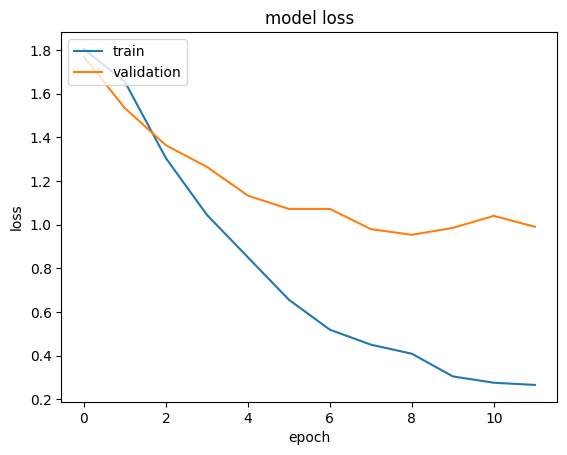

In [22]:
plt.plot(train_losses)
plt.plot(val_losses)
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'validation'], loc='upper left')
plt.show()

In [23]:
model.eval()

with torch.no_grad():
    X_test = test_X.to(device)
    y_test = test_y.to(device)

    outputs = model(X_test)
    preds = torch.argmax(outputs, dim=1)
    test_acc = (preds == y_test).sum().item() / len(y_test)

print(f"Test accuracy: {test_acc:.4f}")

Test accuracy: 0.7196


In [24]:
print(classification_report(y_test.cpu().numpy(), preds.cpu().numpy()))

              precision    recall  f1-score   support

           0       0.69      0.56      0.62       393
           1       0.86      0.67      0.76       384
           2       0.56      0.66      0.61       393
           3       0.86      0.78      0.82       396
           4       0.54      0.73      0.62       343
           5       0.89      0.90      0.90       413

    accuracy                           0.72      2322
   macro avg       0.74      0.72      0.72      2322
weighted avg       0.74      0.72      0.72      2322



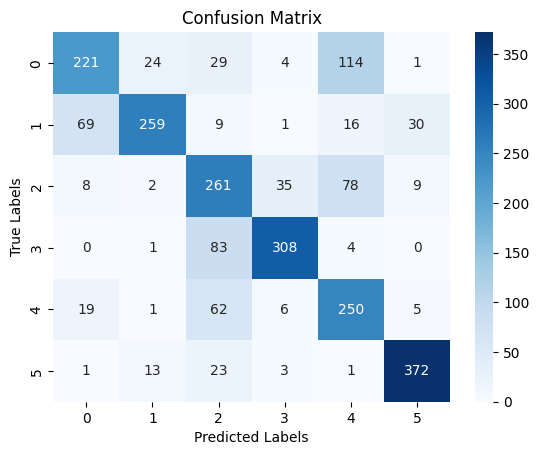

In [25]:
cm = confusion_matrix(
    y_test.cpu().numpy(),
    preds.cpu().numpy()
)

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.title("Confusion Matrix")
plt.show()